# Ekstraliga 2025 — Exploratory Data Analysis
**Quoc Dat Nguyen | MSDS | Boston University**

This notebook explores the Polish Ekstraliga 2025 PA Logs dataset before modelling.
Key questions:
- What does the outcome distribution look like? Is it balanced?
- How many plate appearances do players have? Is the data sparse?
- What pitch sequences are most common?
- How do Markov transition probabilities behave?
- What does the transfer learning training signal look like?

In [8]:
import sys, json
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from preprocessing import build_pa_dataframe
from features import (
    compute_batter_tendencies, compute_pitcher_tendencies,
    build_feature_matrix, train_val_test_split, OUTCOME_CATEGORIES
)
from models.markov import OutcomeMarkov, PitchTransitionMarkov

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
%matplotlib inline

XLSX = '../data/ekstraliga/2025_Ekstraliga_Stats.xlsx'
print('Libraries loaded.')

Libraries loaded.


---
## 1. Load & Preview Data

In [9]:
pa_df = build_pa_dataframe(XLSX)
print(f'Total plate appearances : {len(pa_df):,}')
print(f'Unique batters           : {pa_df["batter"].nunique()}')
print(f'Unique pitchers          : {pa_df["pitcher"].nunique()}')
print(f'Unique teams             : {pa_df["team"].nunique()}')
print(f'Date range               : {pa_df["date"].min()} → {pa_df["date"].max()}')
print(f'Avg pitches per PA       : {pa_df["seq_len"].mean():.2f}')
pa_df[['batter','pitcher','batter_hand','pitcher_hand','sequence','result','result_category']].head(8)

[preprocessing] Loaded 6950 plate appearances ({'OUT': 2072, 'K': 1503, 'HIT': 1123, 'BB': 1024, 'REACH': 555, 'XBH': 351, 'HBP': 232, 'HR': 89, 'OTHER': 1})
Total plate appearances : 6,950
Unique batters           : 176
Unique pitchers          : 85
Unique teams             : 8
Date range               : 2025.04.12 → 2025.10.5
Avg pitches per PA       : 2.65


,batter,pitcher,batter_hand,pitcher_hand,sequence,result,result_category
0,"Stanoszek, Patryk","Richmond, Phillip",RHB,RHP,[B],FO,OUT
1,"Szczygieł, Patryk","Richmond, Phillip",RHB,RHP,"[Sw, Sw]",Kc,K
2,"Michna, Patryk","Richmond, Phillip",RHB,RHP,"[F, B, B, B, Sc]",Ks,K
3,"Polonek, Aleks","Richmond, Phillip",RHB,RHP,[Sc],GO,OUT
4,"Sitko, Paweł","Richmond, Phillip",RHB,RHP,[B],GO,OUT
5,"Chorobik, Olaf","Richmond, Phillip",RHB,RHP,"[Sw, Sw]",ROE,REACH
6,"Pełka, Roman","Richmond, Phillip",RHB,RHP,"[Sw, Sw]",Kc,K
7,"Myrek, Norbert","Richmond, Phillip",RHB,RHP,"[Sc, Sw]",Ks,K


---
## 2. Outcome Distribution
The dataset has 9 outcome categories. Understanding their frequencies reveals class imbalance — a key challenge for model training.

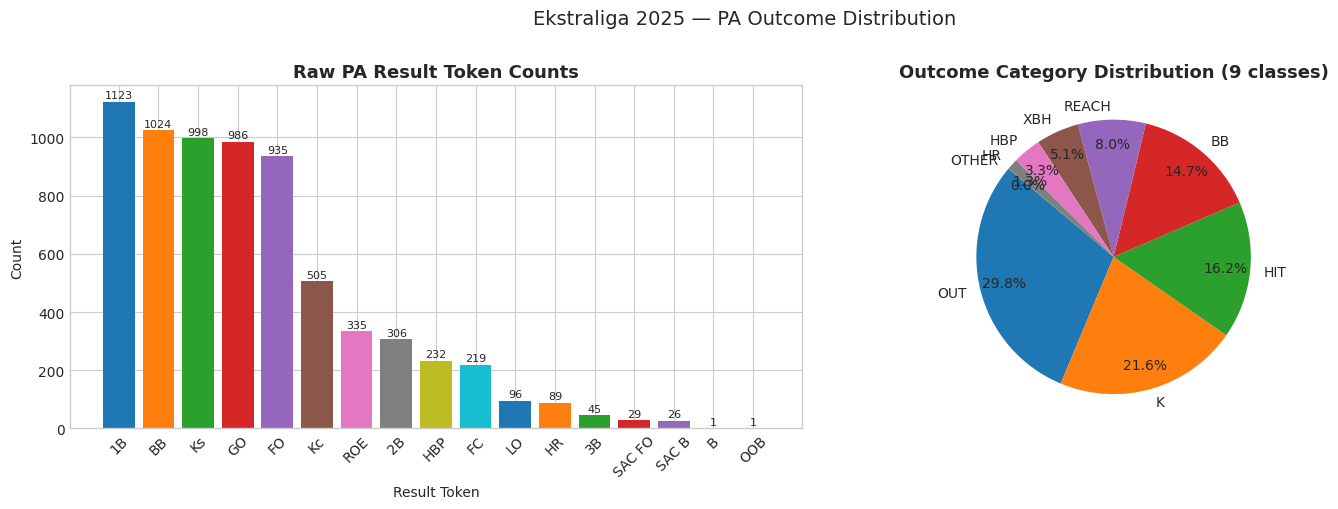


Class imbalance ratio (most common / least common): 2072.0x
Most common outcome: OUT (2072 PAs)
Least common outcome: OTHER (1 PAs)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left: raw result token counts ---
result_counts = pa_df['result'].value_counts()
colors = sns.color_palette('tab10', len(result_counts))
bars = axes[0].bar(result_counts.index, result_counts.values, color=colors)
axes[0].set_title('Raw PA Result Token Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Result Token')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, result_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontsize=8)

# --- Right: coarse category pie ---
cat_counts = pa_df['result_category'].value_counts()
wedge_colors = sns.color_palette('tab10', len(cat_counts))
axes[1].pie(cat_counts.values, labels=cat_counts.index,
            autopct='%1.1f%%', colors=wedge_colors,
            startangle=140, pctdistance=0.82)
axes[1].set_title('Outcome Category Distribution (9 classes)', fontsize=13, fontweight='bold')

plt.suptitle('Ekstraliga 2025 — PA Outcome Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClass imbalance ratio (most common / least common):', 
      f'{cat_counts.max() / cat_counts.min():.1f}x')
print('Most common outcome:', cat_counts.idxmax(), f'({cat_counts.max()} PAs)')
print('Least common outcome:', cat_counts.idxmin(), f'({cat_counts.min()} PAs)')

**Finding:** The dataset is heavily imbalanced. OUT is the most common outcome (~30%), while OTHER appears only once. HR and HBP are rare. This imbalance is why we use class-weighted loss during LSTM training.

## 3. Player Plate Appearance Distribution

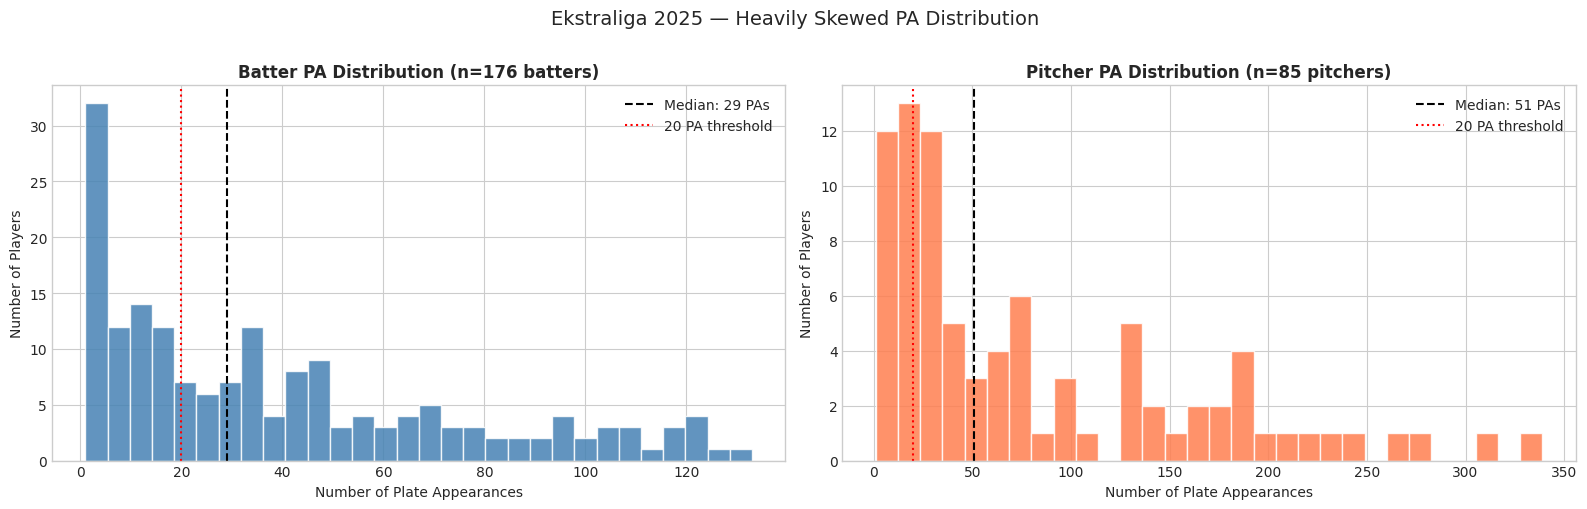

Batters with < 20 PAs  : 71 / 176 (40.3%)
Pitchers with < 20 PAs : 23 / 85 (27.1%)

Batter PA stats:
count    176.0
mean      39.5
std       35.8
min        1.0
25%        9.8
50%       29.0
75%       62.0
max      133.0
Name: count, dtype: float64


In [11]:
batter_pa_counts  = pa_df['batter'].value_counts()
pitcher_pa_counts = pa_df['pitcher'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, counts, title, color in [
    (axes[0], batter_pa_counts,  'Batter PA Distribution (n=176 batters)',  'steelblue'),
    (axes[1], pitcher_pa_counts, 'Pitcher PA Distribution (n=85 pitchers)', 'coral'),
]:
    ax.hist(counts.values, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(counts.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {counts.median():.0f} PAs')
    ax.axvline(20, color='red', linestyle=':', linewidth=1.5,
               label='20 PA threshold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Plate Appearances')
    ax.set_ylabel('Number of Players')
    ax.legend()

plt.suptitle('Ekstraliga 2025 — Heavily Skewed PA Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('pa_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
below_20_bat = (batter_pa_counts < 20).sum()
below_20_pit = (pitcher_pa_counts < 20).sum()
print(f'Batters with < 20 PAs  : {below_20_bat} / {len(batter_pa_counts)} ({below_20_bat/len(batter_pa_counts):.1%})')
print(f'Pitchers with < 20 PAs : {below_20_pit} / {len(pitcher_pa_counts)} ({below_20_pit/len(pitcher_pa_counts):.1%})')
print(f'\nBatter PA stats:')
print(batter_pa_counts.describe().round(1))

**Finding:** This is the core data problem. The distribution is extremely right-skewed. The median batter has only ~30 PAs, and over half the players appear fewer than 20 times. Tendency features (K%, BB%, swing rate) computed from so few observations are noisy and unreliable — which directly explains why the Markov model, which ignores player identity entirely, can still outperform the LSTM.

---
## 4. Top & Bottom Players by PA Volume

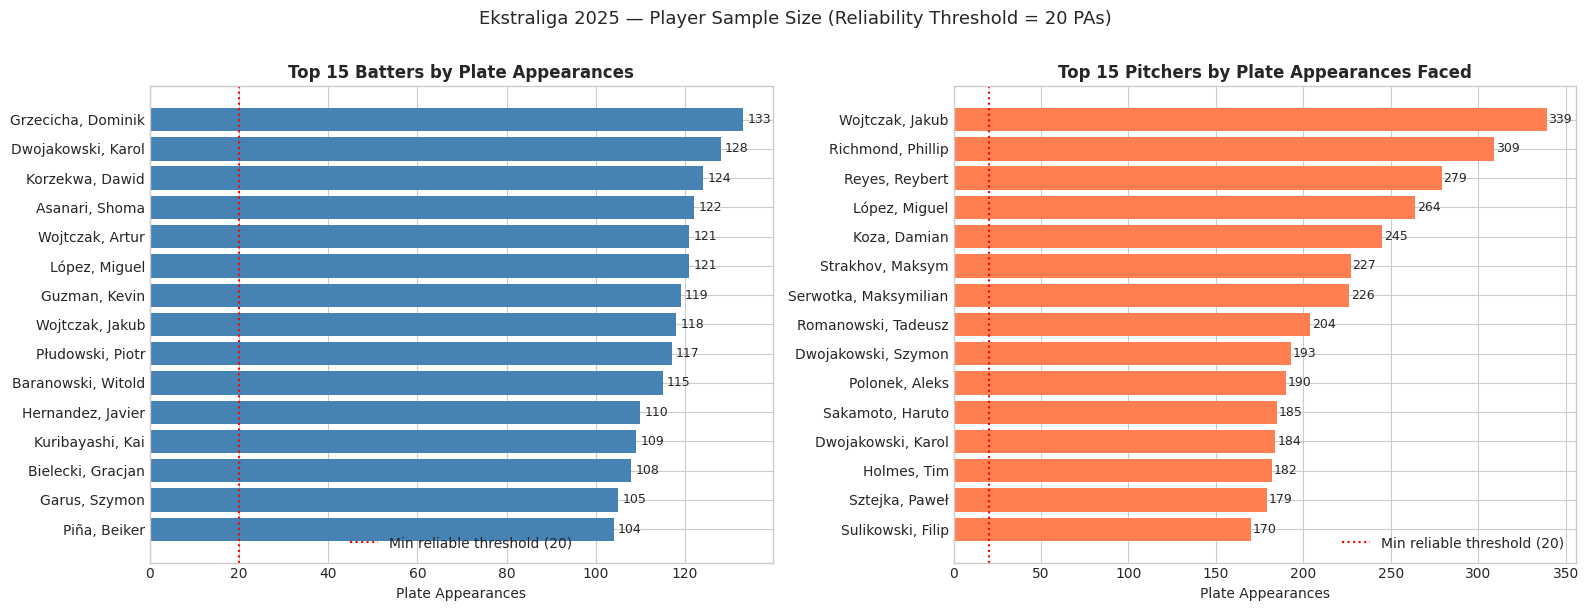

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 batters
top_bat = batter_pa_counts.head(15)
bars = axes[0].barh(top_bat.index[::-1], top_bat.values[::-1], color='steelblue')
axes[0].axvline(20, color='red', linestyle=':', linewidth=1.5, label='Min reliable threshold (20)')
axes[0].set_title('Top 15 Batters by Plate Appearances', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Plate Appearances')
for bar, val in zip(bars, top_bat.values[::-1]):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[0].legend()

# Top 15 pitchers
top_pit = pitcher_pa_counts.head(15)
bars = axes[1].barh(top_pit.index[::-1], top_pit.values[::-1], color='coral')
axes[1].axvline(20, color='red', linestyle=':', linewidth=1.5, label='Min reliable threshold (20)')
axes[1].set_title('Top 15 Pitchers by Plate Appearances Faced', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Plate Appearances')
for bar, val in zip(bars, top_pit.values[::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[1].legend()

plt.suptitle('Ekstraliga 2025 — Player Sample Size (Reliability Threshold = 20 PAs)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('top_players_pa.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Team Distribution & Handedness

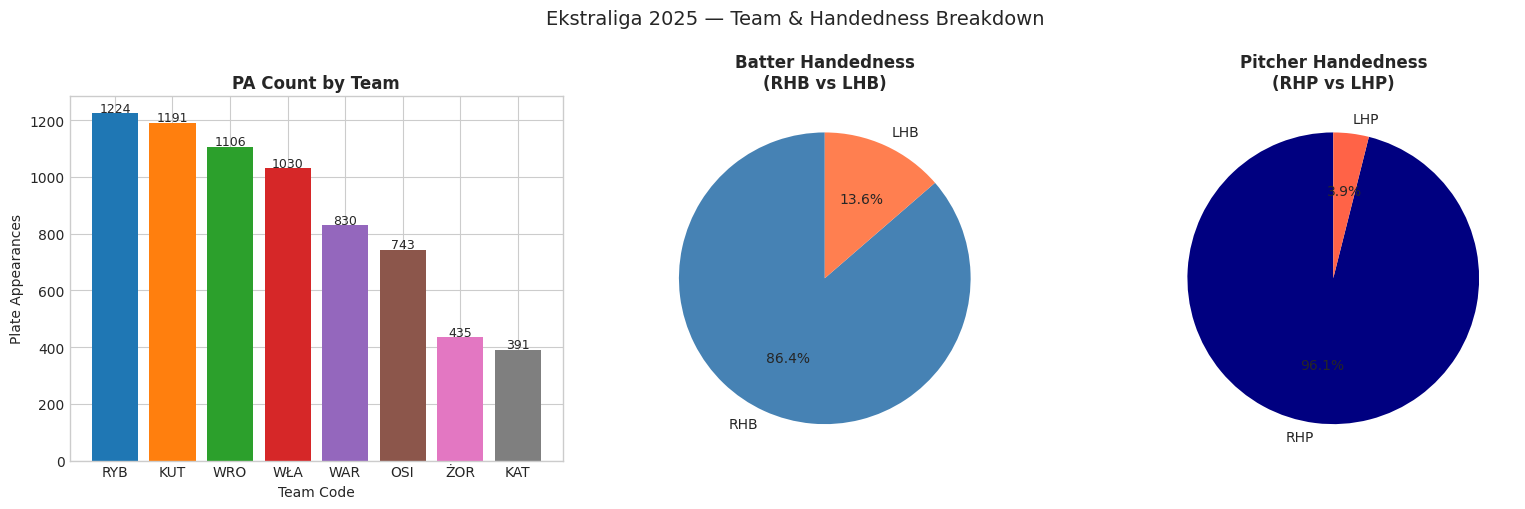

Note: RHP dominate (96% of pitchers). Very few LHP means the model
has almost no training signal for platoon advantage involving LHP.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Team PA counts
team_counts = pa_df['team'].value_counts()
axes[0].bar(team_counts.index, team_counts.values, color=sns.color_palette('tab10', len(team_counts)))
axes[0].set_title('PA Count by Team', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Team Code')
axes[0].set_ylabel('Plate Appearances')
for i, (team, val) in enumerate(team_counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontsize=9)

# Batter handedness
hand_b = pa_df['batter_hand'].value_counts()
axes[1].pie(hand_b.values, labels=hand_b.index,
            autopct='%1.1f%%', colors=['steelblue','coral'],
            startangle=90)
axes[1].set_title('Batter Handedness\n(RHB vs LHB)', fontsize=12, fontweight='bold')

# Pitcher handedness
hand_p = pa_df['pitcher_hand'].value_counts()
axes[2].pie(hand_p.values, labels=hand_p.index,
            autopct='%1.1f%%', colors=['navy','tomato'],
            startangle=90)
axes[2].set_title('Pitcher Handedness\n(RHP vs LHP)', fontsize=12, fontweight='bold')

plt.suptitle('Ekstraliga 2025 — Team & Handedness Breakdown', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('team_handedness.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: RHP dominate (96% of pitchers). Very few LHP means the model')
print('has almost no training signal for platoon advantage involving LHP.')

---
## 6. Sequence Length Distribution
How many pitches does a typical plate appearance last?

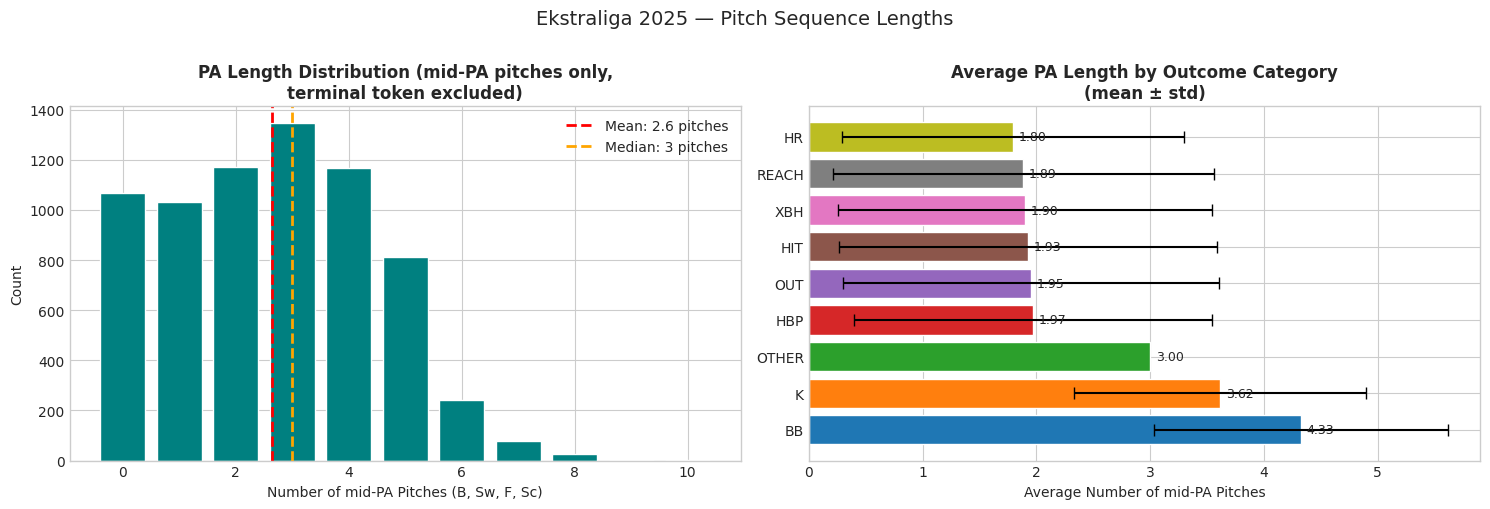

count    6950.00
mean        2.65
std         1.81
min         0.00
25%         1.00
50%         3.00
75%         4.00
max        10.00
Name: seq_len, dtype: float64

PAs with 0 mid-PA pitches (first pitch terminal): 1069 (15.4%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Overall distribution
seq_counts = pa_df['seq_len'].value_counts().sort_index()
axes[0].bar(seq_counts.index, seq_counts.values, color='teal', edgecolor='white')
axes[0].axvline(pa_df['seq_len'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {pa_df["seq_len"].mean():.1f} pitches')
axes[0].axvline(pa_df['seq_len'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median: {pa_df["seq_len"].median():.0f} pitches')
axes[0].set_title('PA Length Distribution (mid-PA pitches only,\nterminal token excluded)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of mid-PA Pitches (B, Sw, F, Sc)')
axes[0].set_ylabel('Count')
axes[0].legend()

# By outcome category
outcome_order = pa_df.groupby('result_category')['seq_len'].mean().sort_values(ascending=False).index
means = [pa_df[pa_df['result_category']==cat]['seq_len'].mean() for cat in outcome_order]
stds  = [pa_df[pa_df['result_category']==cat]['seq_len'].std()  for cat in outcome_order]
colors_out = sns.color_palette('tab10', len(outcome_order))
bars = axes[1].barh(outcome_order, means, xerr=stds, color=colors_out,
                    capsize=4, edgecolor='white')
axes[1].set_title('Average PA Length by Outcome Category\n(mean ± std)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Number of mid-PA Pitches')
for bar, val in zip(bars, means):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)

plt.suptitle('Ekstraliga 2025 — Pitch Sequence Lengths', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('seq_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(pa_df['seq_len'].describe().round(2))
zero_pitch = (pa_df['seq_len'] == 0).sum()
print(f'\nPAs with 0 mid-PA pitches (first pitch terminal): {zero_pitch} ({zero_pitch/len(pa_df):.1%})')

**Finding:** Walks and strikeouts tend to have longer sequences (more pitches), while outs in play are shorter. Many PAs end on the first pitch (seq_len = 0), meaning the model has no sequence context at all for those — it must rely entirely on tendency features.

---
## 7. Pitch Token Frequency
What types of pitches are most common mid-PA?

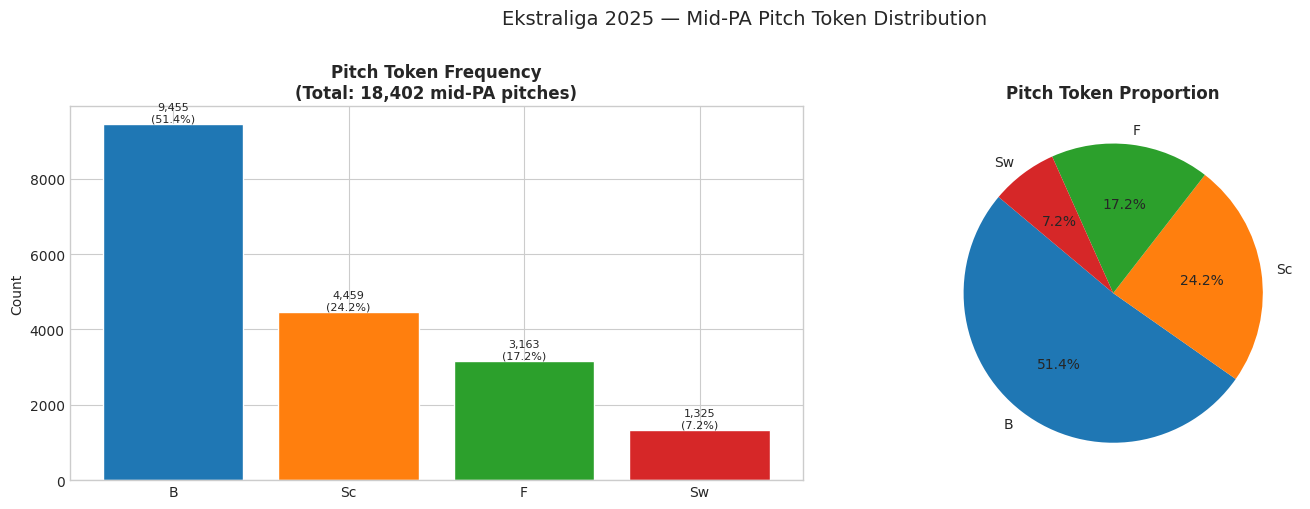

Token breakdown:
     B :  9,455  (51.4%)
    Sc :  4,459  (24.2%)
     F :  3,163  (17.2%)
    Sw :  1,325  (7.2%)


In [15]:
all_tokens = [tok for seq in pa_df['sequence'] for tok in seq]
token_counts = Counter(all_tokens)
total_pitches = sum(token_counts.values())

labels, vals = zip(*sorted(token_counts.items(), key=lambda x: -x[1]))
pcts = [v/total_pitches*100 for v in vals]
colors_tok = sns.color_palette('tab10', len(labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
bars = axes[0].bar(labels, vals, color=colors_tok, edgecolor='white')
axes[0].set_title(f'Pitch Token Frequency\n(Total: {total_pitches:,} mid-PA pitches)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val, pct in zip(bars, vals, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

# Pie
axes[1].pie(vals, labels=labels, autopct='%1.1f%%',
            colors=colors_tok, startangle=140)
axes[1].set_title('Pitch Token Proportion', fontsize=12, fontweight='bold')

plt.suptitle('Ekstraliga 2025 — Mid-PA Pitch Token Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('token_freq.png', dpi=150, bbox_inches='tight')
plt.show()

print('Token breakdown:')
for label, val, pct in zip(labels, vals, pcts):
    print(f'  {label:>4} : {val:>6,}  ({pct:.1f}%)')

---
## 8. Markov Transition Matrix
Given the current pitch, what is the probability of each next pitch?

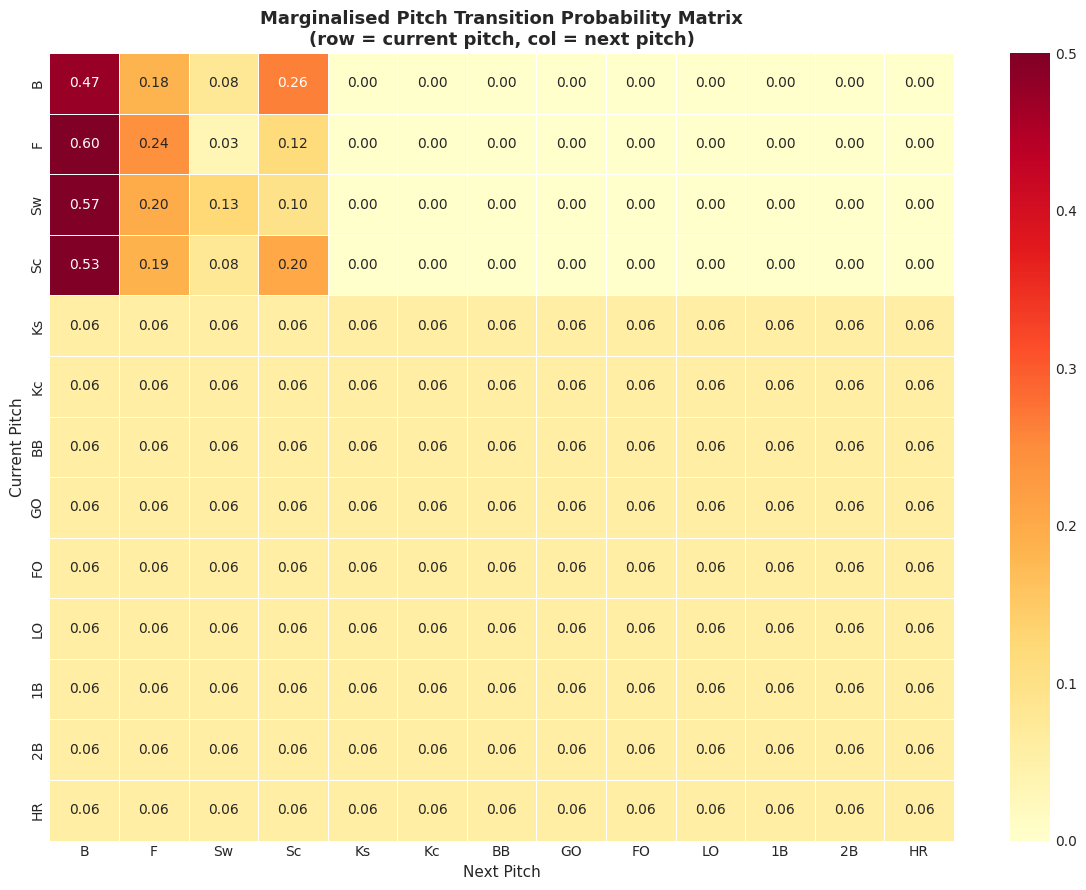

Key observations:
  - After a Ball (B), another Ball is most likely
  - After a Swinging Strike (Sw), a Strikeout (Ks) becomes likely
  - After a Foul (F), another Foul or a Swinging Strike is most likely


In [16]:
markov = PitchTransitionMarkov(smoothing=0.1)
markov.fit(pa_df)

trans = markov.transition_matrix_df()
show_tokens = ['B', 'F', 'Sw', 'Sc', 'Ks', 'Kc', 'BB', 'GO', 'FO', 'LO', '1B', '2B', 'HR']
trans_sub = trans.loc[
    [t for t in show_tokens if t in trans.index],
    [t for t in show_tokens if t in trans.columns]
]

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(trans_sub, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=0.5)
ax.set_title('Marginalised Pitch Transition Probability Matrix\n'
             '(row = current pitch, col = next pitch)', fontsize=13, fontweight='bold')
ax.set_xlabel('Next Pitch', fontsize=11)
ax.set_ylabel('Current Pitch', fontsize=11)

plt.tight_layout()
plt.savefig('markov_transition.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key observations:')
print('  - After a Ball (B), another Ball is most likely')
print('  - After a Swinging Strike (Sw), a Strikeout (Ks) becomes likely')
print('  - After a Foul (F), another Foul or a Swinging Strike is most likely')

---
## 9. Count State → Outcome Heatmap
The Markov baseline predicts outcomes purely from the final count (balls, strikes). This heatmap shows why it works.

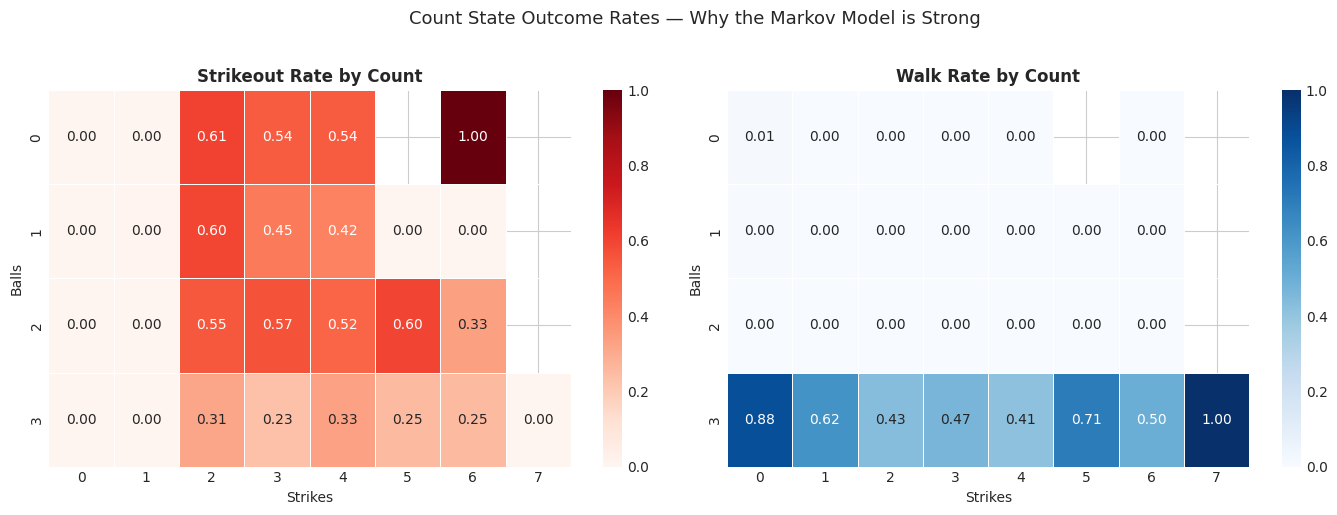

Key insight: K rate spikes dramatically at 2-strike counts.
BB rate spikes at 3-ball counts. Count state is highly predictive.


In [17]:
# Build count-state outcome probability table
count_outcome = pa_df.groupby(['balls_final', 'strikes_final', 'result_category']).size().unstack(fill_value=0)
count_outcome_pct = count_outcome.div(count_outcome.sum(axis=1), axis=0)

# Show K and BB rates by count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cat, title, cmap in [
    (axes[0], 'K',  'Strikeout Rate by Count', 'Reds'),
    (axes[1], 'BB', 'Walk Rate by Count',       'Blues'),
]:
    if cat not in count_outcome_pct.columns:
        continue
    pivot = count_outcome_pct[cat].unstack(level='strikes_final')
    pivot.index.name   = 'Balls'
    pivot.columns.name = 'Strikes'
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap=cmap,
                ax=ax, vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Strikes')
    ax.set_ylabel('Balls')

plt.suptitle('Count State Outcome Rates — Why the Markov Model is Strong', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('count_outcome_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key insight: K rate spikes dramatically at 2-strike counts.')
print('BB rate spikes at 3-ball counts. Count state is highly predictive.')

---
## 10. Player Tendency Analysis
Comparing top batters and pitchers by computed tendency features.

Batters with ≥20 PA: 105 / 176 (59.7%)
Pitchers with ≥20 PA: 62 / 85 (72.9%)


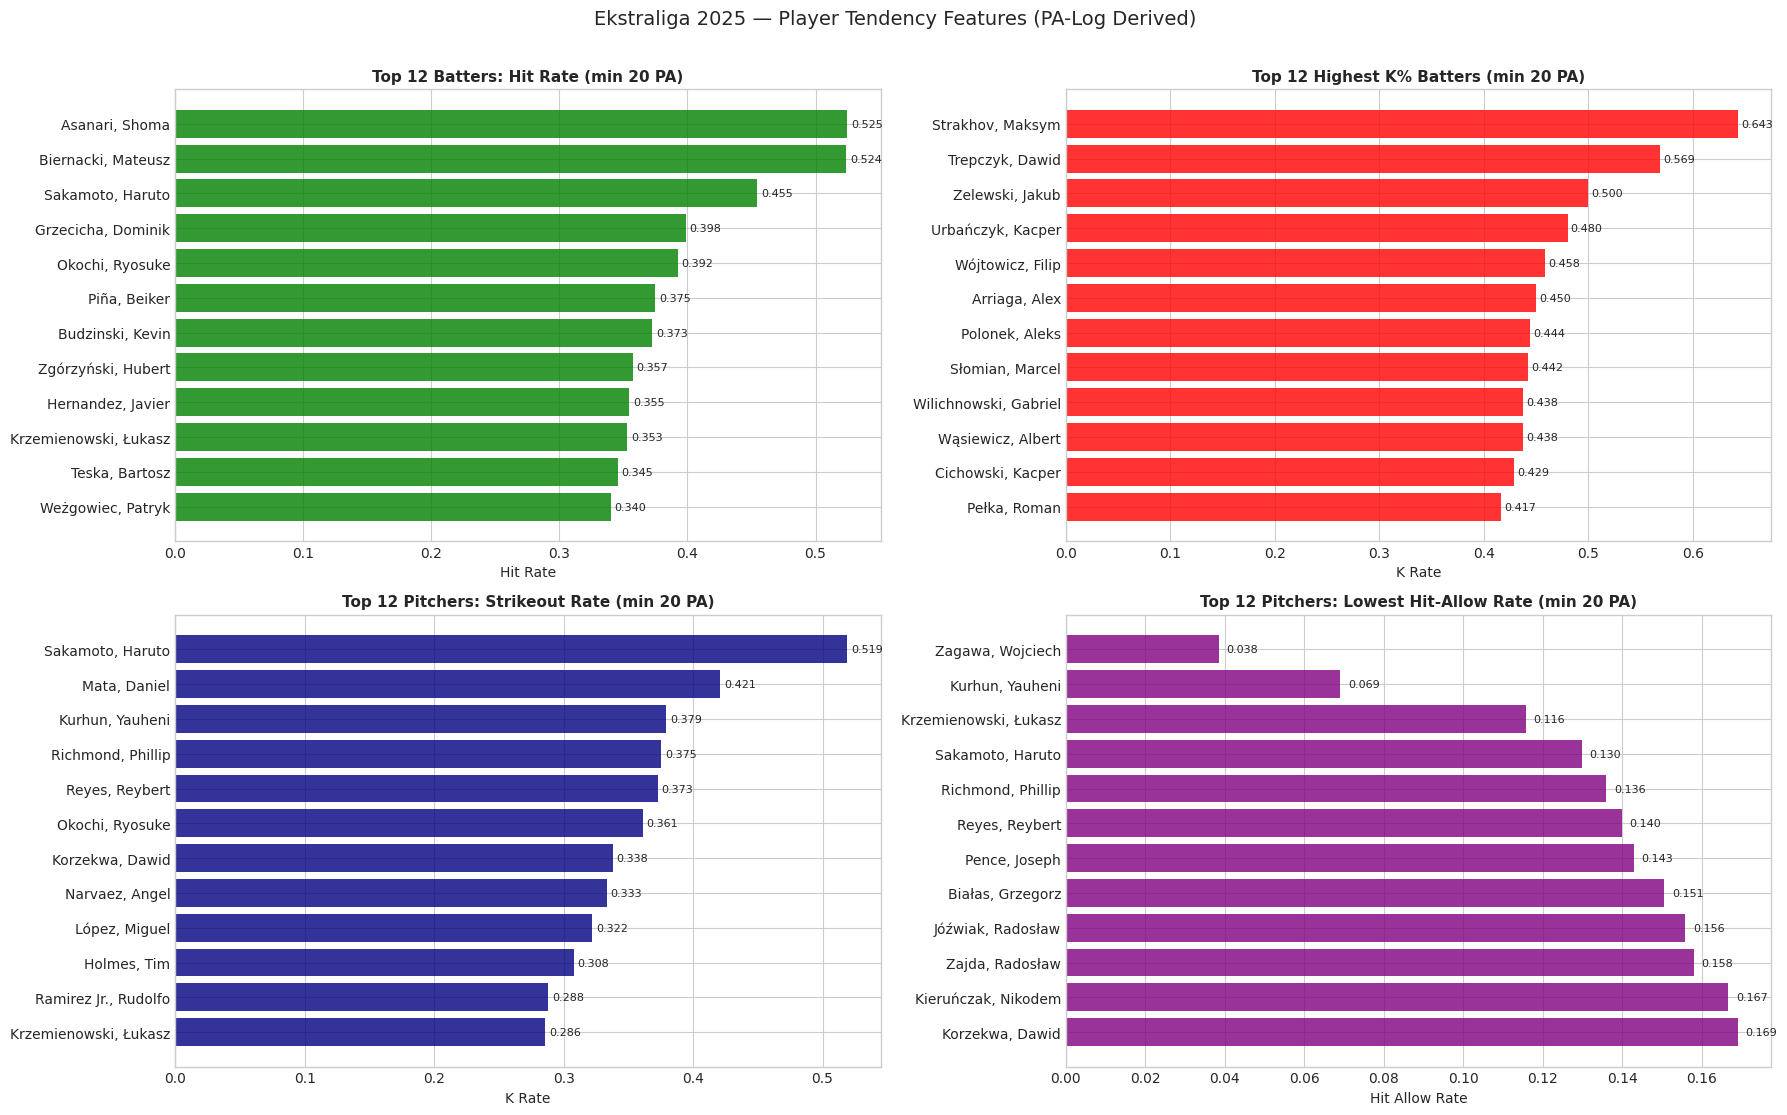

In [18]:
bt = compute_batter_tendencies(pa_df)
pt = compute_pitcher_tendencies(pa_df)

# Only reliable players (min 20 PA)
bt_q = bt[bt['batter_n_pa'] >= 20].copy()
pt_q = pt[pt['pitcher_n_pa'] >= 20].copy()

print(f'Batters with ≥20 PA: {len(bt_q)} / {len(bt)} ({len(bt_q)/len(bt):.1%})')
print(f'Pitchers with ≥20 PA: {len(pt_q)} / {len(pt)} ({len(pt_q)/len(pt):.1%})')

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# Top hitters
top_hit = bt_q.nlargest(12, 'hit_rate')['hit_rate']
axes[0,0].barh(top_hit.index[::-1], top_hit.values[::-1], color='green', alpha=0.8)
axes[0,0].set_title('Top 12 Batters: Hit Rate (min 20 PA)', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Hit Rate')
for i, val in enumerate(top_hit.values[::-1]):
    axes[0,0].text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=8)

# Highest K batters
top_k = bt_q.nlargest(12, 'k_rate')['k_rate']
axes[0,1].barh(top_k.index[::-1], top_k.values[::-1], color='red', alpha=0.8)
axes[0,1].set_title('Top 12 Highest K% Batters (min 20 PA)', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('K Rate')
for i, val in enumerate(top_k.values[::-1]):
    axes[0,1].text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=8)

# Top pitcher K rate
top_p_k = pt_q.nlargest(12, 'pitcher_k_rate')['pitcher_k_rate']
axes[1,0].barh(top_p_k.index[::-1], top_p_k.values[::-1], color='navy', alpha=0.8)
axes[1,0].set_title('Top 12 Pitchers: Strikeout Rate (min 20 PA)', fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('K Rate')
for i, val in enumerate(top_p_k.values[::-1]):
    axes[1,0].text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=8)

# Best pitchers (lowest hit allow)
top_p_h = pt_q.nsmallest(12, 'pitcher_hit_allow')['pitcher_hit_allow']
axes[1,1].barh(top_p_h.index[::-1], top_p_h.values[::-1], color='purple', alpha=0.8)
axes[1,1].set_title('Top 12 Pitchers: Lowest Hit-Allow Rate (min 20 PA)', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Hit Allow Rate')
for i, val in enumerate(top_p_h.values[::-1]):
    axes[1,1].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Ekstraliga 2025 — Player Tendency Features (PA-Log Derived)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('player_tendencies.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. MLB vs Ekstraliga: Dataset Comparison

In [19]:
try:
    import glob
    from mlb_preprocessing import build_mlb_pa_dataframe
    mlb_pkl = 'data/mlb/mlb_pa_clean.pkl'
    mlb_df = pd.read_pickle(mlb_pkl)
    has_mlb = True
    print(f'MLB data loaded: {len(mlb_df):,} PAs')
except Exception as e:
    has_mlb = False
    print(f'MLB data not available: {e}')

if has_mlb:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Dataset size comparison
    datasets   = ['MLB\n(2024 sample)', 'Ekstraliga\n(2025)']
    sizes      = [len(mlb_df), len(pa_df)]
    bar_colors = ['#1f77b4', '#ff7f0e']
    bars = axes[0].bar(datasets, sizes, color=bar_colors, edgecolor='white', width=0.5)
    axes[0].set_title('Dataset Size', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Plate Appearances')
    for bar, val in zip(bars, sizes):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                     f'{val:,}', ha='center', fontsize=11, fontweight='bold')

    # Sequence length comparison
    mlb_seq_len = mlb_df['sequence'].apply(lambda s: len(s) if isinstance(s, list) else 0)
    axes[1].hist(pa_df['seq_len'],  bins=12, alpha=0.7, color='#ff7f0e', label='Ekstraliga', density=True)
    axes[1].hist(mlb_seq_len,       bins=12, alpha=0.7, color='#1f77b4', label='MLB',        density=True)
    axes[1].axvline(pa_df['seq_len'].mean(),  color='#ff7f0e', linestyle='--', linewidth=2)
    axes[1].axvline(mlb_seq_len.mean(),       color='#1f77b4', linestyle='--', linewidth=2)
    axes[1].set_title('Sequence Length Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Pitches per PA')
    axes[1].set_ylabel('Density')
    axes[1].legend()

    # Outcome distribution comparison
    mlb_cats = mlb_df['result_category'].value_counts(normalize=True).reindex(OUTCOME_CATEGORIES, fill_value=0)
    ek_cats  = pa_df['result_category'].value_counts(normalize=True).reindex(OUTCOME_CATEGORIES, fill_value=0)
    x = np.arange(len(OUTCOME_CATEGORIES))
    w = 0.35
    axes[2].bar(x - w/2, mlb_cats.values, w, label='MLB',        color='#1f77b4', alpha=0.8)
    axes[2].bar(x + w/2, ek_cats.values,  w, label='Ekstraliga', color='#ff7f0e', alpha=0.8)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(OUTCOME_CATEGORIES, rotation=45, ha='right')
    axes[2].set_title('Outcome Distribution Comparison', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Proportion')
    axes[2].legend()

    plt.suptitle('MLB vs Ekstraliga — Dataset Comparison', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('mlb_vs_ekstra.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping MLB comparison — run mlb_api.py first to generate data.')

MLB data not available: [Errno 2] No such file or directory: 'data/mlb/mlb_pa_clean.pkl'
Skipping MLB comparison — run mlb_api.py first to generate data.


---
## 12. Transfer Learning Results
Training curves from the three-phase transfer learning pipeline.

In [20]:
import glob, os

# Find the most recent transfer run
run_dirs = sorted(glob.glob('runs/transfer_*'))
run_dir  = run_dirs[-1] if run_dirs else None
print(f'Using run: {run_dir}')

def load_hist(path):
    try:
        return json.load(open(path))
    except:
        return None

if run_dir:
    p1 = load_hist(f'{run_dir}/mlb_pretrained_history.json')
    p2 = load_hist(f'{run_dir}/ekstra_frozen_history.json')
    p3 = load_hist(f'{run_dir}/ekstra_full_history.json')
    bs = load_hist(f'{run_dir}/scratch_model_history.json')

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Val accuracy
    if bs: axes[0].plot([r['epoch'] for r in bs], [r['val_acc'] for r in bs],
                        label='Scratch baseline', linewidth=2, color='#1f77b4')
    if p2: axes[0].plot([r['epoch'] for r in p2], [r['val_acc'] for r in p2],
                        label='Phase 2 — frozen encoder', linewidth=2, color='#ff7f0e')
    if p3: axes[0].plot([r['epoch'] for r in p3], [r['val_acc'] for r in p3],
                        label='Phase 3 — full fine-tune', linewidth=2, color='#2ca02c')
    axes[0].axhline(y=1/9, color='gray', linestyle='--', linewidth=1.5, label='Random chance (11.1%)')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Accuracy')
    axes[0].set_title('Validation Accuracy — Transfer Learning vs Scratch', fontsize=12, fontweight='bold')
    axes[0].legend(); axes[0].set_ylim(0, 0.6)

    # Val loss
    if bs: axes[1].plot([r['epoch'] for r in bs], [r['val_loss'] for r in bs],
                        label='Scratch baseline', linewidth=2, color='#1f77b4')
    if p2: axes[1].plot([r['epoch'] for r in p2], [r['val_loss'] for r in p2],
                        label='Phase 2 — frozen encoder', linewidth=2, color='#ff7f0e')
    if p3: axes[1].plot([r['epoch'] for r in p3], [r['val_loss'] for r in p3],
                        label='Phase 3 — full fine-tune', linewidth=2, color='#2ca02c')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Loss')
    axes[1].set_title('Validation Loss — Transfer Learning vs Scratch', fontsize=12, fontweight='bold')
    axes[1].legend()

    plt.suptitle('MLB → Ekstraliga Transfer Learning — Training Curves', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('transfer_learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No transfer run found. Run transfer_train.py first.')

Using run: None
No transfer run found. Run transfer_train.py first.


---
## 13. Model Comparison Summary

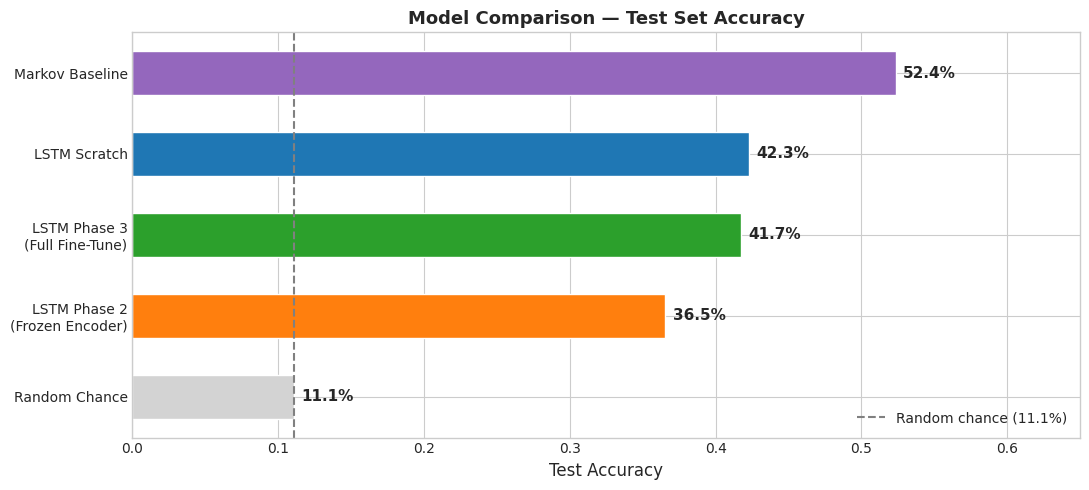

Key takeaways:
  - All models beat random chance (11.1%) by 3-4x
  - Markov wins: count state is highly predictive in small datasets
  - Transfer learning (Phase 3) nearly matches scratch performance
  - Frozen encoder (Phase 2) hurts: MLB domain too different from Ekstraliga


In [21]:
# Results from runs
results = {
    'Random Chance':                  {'test_acc': 1/9,  'color': 'lightgray'},
    'Markov Baseline':                {'test_acc': 0.5237, 'color': '#9467bd'},
    'LSTM Scratch':                   {'test_acc': 0.4230, 'color': '#1f77b4'},
    'LSTM Phase 3\n(Full Fine-Tune)': {'test_acc': 0.4173, 'color': '#2ca02c'},
    'LSTM Phase 2\n(Frozen Encoder)': {'test_acc': 0.3655, 'color': '#ff7f0e'},
}

# Sort by accuracy
sorted_results = dict(sorted(results.items(), key=lambda x: x[1]['test_acc']))

fig, ax = plt.subplots(figsize=(11, 5))
labels  = list(sorted_results.keys())
accs    = [v['test_acc'] for v in sorted_results.values()]
colors  = [v['color']    for v in sorted_results.values()]

bars = ax.barh(labels, accs, color=colors, edgecolor='white', height=0.55)
ax.axvline(1/9, color='gray', linestyle='--', linewidth=1.5, label='Random chance (11.1%)')
ax.set_xlabel('Test Accuracy', fontsize=12)
ax.set_title('Model Comparison — Test Set Accuracy', fontsize=13, fontweight='bold')
ax.set_xlim(0, 0.65)
ax.legend()

for bar, val in zip(bars, accs):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key takeaways:')
print('  - All models beat random chance (11.1%) by 3-4x')
print('  - Markov wins: count state is highly predictive in small datasets')
print('  - Transfer learning (Phase 3) nearly matches scratch performance')
print('  - Frozen encoder (Phase 2) hurts: MLB domain too different from Ekstraliga')

---
## 14. Key Findings Summary

| Finding | Implication |
|---|---|
| 176 batters, median 29.5 PAs, 25th pct = 9.75 PAs | Player tendency features are noisy for most players |
| 9-class outcome imbalance (30% OUT, <1% OTHER) | Class-weighted loss required; rare outcomes hard to predict |
| 96% of pitchers are RHP | Platoon advantage has almost no LHP signal to learn from |
| Average PA length = ~1.5 mid-PA pitches | Very short sequences; sequence model has little to work with |
| Count state predicts outcome well (Markov 52%) | Confirms count is the dominant feature in this data regime |
| Transfer learning converges faster early | MLB pretraining provides better initialization than random |
| Frozen encoder hurts accuracy | MLB domain gap too large for zero-shot encoder transfer |